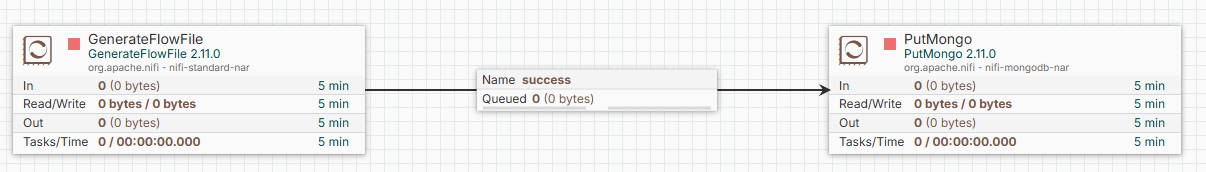

In [1]:
# Характер данных для передачи: {"exchange":"NiFiTest","volume_1":10.5,"volume_2":12.1,"volume_3":9.8,"volume_4":11.0,"volume_5":8.4,"volume_6":7.2}

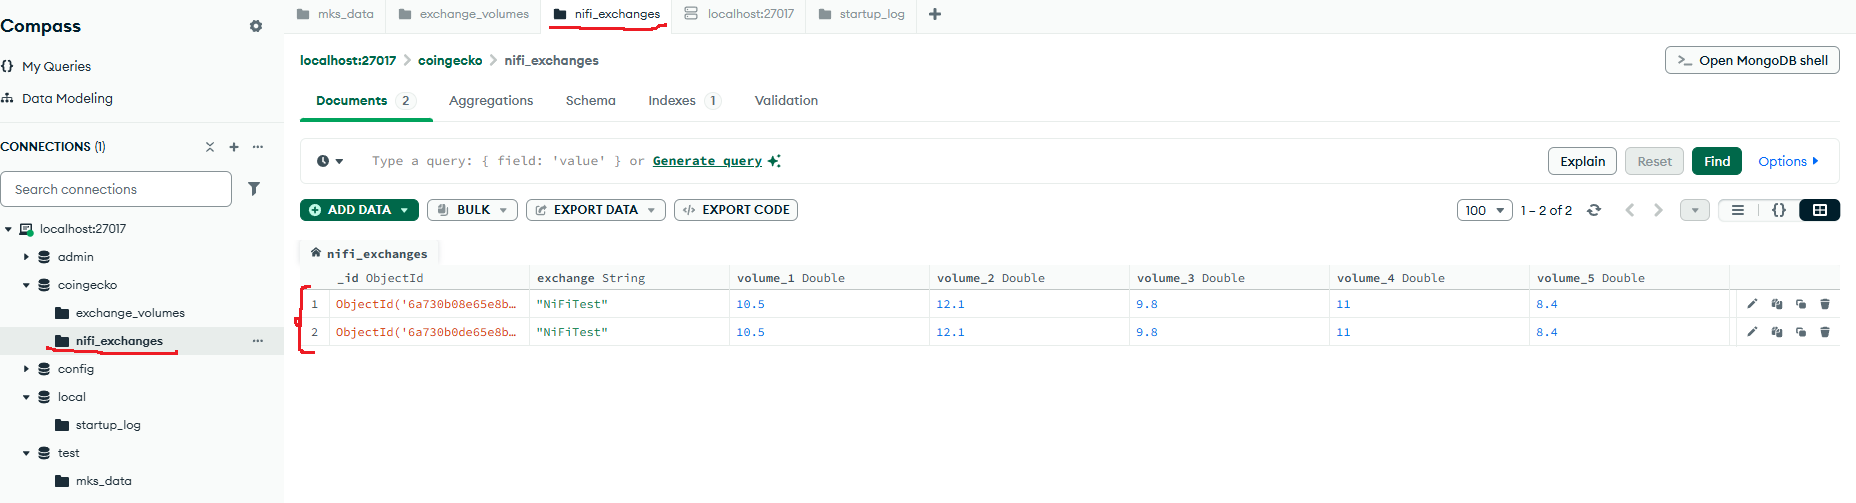

GenerateFlowFile  →  PutMongo
                       ↑
              MongoDBControllerService
              (mongodb://host.docker.internal:27017)

GenerateFlowFile создаёт FlowFile с JSON-содержимым и по связи success передаёт его в PutMongo. PutMongo сам не хранит адрес MongoDB — он обращается к MongoDBControllerService, который знает, куда подключаться, устанавливает соединение с базой и вставляет документ в указанную коллекцию. Таким образом, процессор отвечает только за запись данных, а все настройки подключения сосредоточены в одном общем контроллере.

## Controller Service

**Тип:** `MongoDBControllerService`

| Property | Value |
|----------|--------|
| Mongo URI | `mongodb://host.docker.internal:27017` |

Статус: **Enabled** (зелёный).

> `host.docker.internal` — адрес хоста Windows из Docker-контейнера NiFi.
## GenerateFlowFile

| Property | Value |
|----------|--------|
| Custom Text | `{"exchange":"NiFiTest","volume_1":10.5,"volume_2":12.1,"volume_3":9.8,"volume_4":11.0,"volume_5":8.4,"volume_6":7.2}` |

**Relationships**
- `success` → соединить с PutMongo
- остальные → **terminate**

**Scheduling** (опционально)
- Run Schedule: `5 sec` — генерировать каждые 5 секунд
## PutMongo

| Property | Value |
|----------|--------|
| Mongo Controller Service | `MongoDBControllerService` |
| Database Name | `coingecko` |
| Collection Name | `nifi_exchanges` |
| Mode | `insert` |

**Relationships**
- `success` → **terminate**
- `failure` → **terminate**
| Без контроллера | С контроллером |
|-----------------|----------------|
| URI прописывается в каждом PutMongo | URI задаётся один раз |
| Смена адреса → править все процессоры | Смена адреса → править только сервис |
| Легко ошибиться в одном из процессоров | Все процессоры используют одну настройку |

---
## Порядок запуска
1. Включить **MongoDBControllerService** (Enable).
2. Start **GenerateFlowFile**.
3. Start **PutMongo**

# Проверка

In [2]:
from pymongo import MongoClient

client = MongoClient("mongodb://localhost:27017/")
col = client["coingecko"]["nifi_exchanges"]

print("Документов:", col.count_documents({}))
for doc in col.find({}, {"_id": 0}).limit(5):
    print(doc)

Документов: 2
{'exchange': 'NiFiTest', 'volume_1': 10.5, 'volume_2': 12.1, 'volume_3': 9.8, 'volume_4': 11.0, 'volume_5': 8.4, 'volume_6': 7.2}
{'exchange': 'NiFiTest', 'volume_1': 10.5, 'volume_2': 12.1, 'volume_3': 9.8, 'volume_4': 11.0, 'volume_5': 8.4, 'volume_6': 7.2}
